# Customer Churn Prediction Project

## Objective
The aim of this project is to build a machine learning model that predicts whether a customer is likely to churn using customer demographic information, account details, service information and spending behaviour.

## 1. Import Libraries

Import the necessary Python libraries for data manipulation, numerical operations, and data visualisation.

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

The Telco Customer Churn dataset will be loaded into a pandas DataFrame for exploration and analysis.

In [227]:
df = pd.read_csv("C:/Users/soreo/OneDrive/Desktop/customer-churn-prediction/data/raw_dataset.csv.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Understanding

Before cleaning the dataset, the data will be explored to understand its structure, features, data types and any potential issues.

In [228]:
df.shape

(7043, 21)

In [229]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [230]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [231]:
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [232]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [233]:
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [234]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [235]:
df.duplicated().sum()
#check for duplicates

0

# Data Understanding Findings

Initial exploration showed:

 The dataset contains 7,043 customers and 21 features
 The dataset includes demographic, account, service and spending information
 The target variable is Churn
 The TotalCharges column requires further investigation due to its incorrect data type
 No duplicate records were identified

## 4. Data Cleaning

The dataset is going to be cleaned by handling missing values, correcting data types, removing unnecessary columns and preparing the data for further analysis and modelling.

In [236]:
df_clean = df.copy()
#create a safe copy of data set

In [237]:
#check for missing values 
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [238]:
df_clean["TotalCharges"].dtype
#data type for 'TotalCharges'

dtype('O')

In [239]:
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

In [240]:
df_clean["TotalCharges"].dtype
#check if data type changed correctly

dtype('float64')

CustomerId doesnt help predict churn as its just a identifyer and doesnt explain behaviour. Therefore its an unnecessary column and will be removed. 

In [241]:
df_clean.drop("customerID", axis=1, inplace=True)

In [242]:
df_clean.duplicated().sum()

22

In [243]:
df_clean["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [244]:
df_clean["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [245]:
df_clean["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [246]:
df_clean.info()
# check clean dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


The dataset decreased slightly after removing the customer identifier column

In [247]:
df.shape


(7043, 21)

In [248]:
df_clean.shape

(7043, 20)

In [249]:
df_clean.to_csv("../data/cleaned_customer_churn.csv", index=False)
#save cleaned dataset to data folder

# 5. Exploratory Data Analysis EDA
Exploratory data analysis is used to understand patterns and relationships within the dataset. This analysis will investigate customer characteristics and identify factors that may affect customer churn.

## Churn Distribution
 Before analysing customer behaviour, the distribution of the churn will be explored to understand how many customers stayed versus how many left.

In [250]:
df_clean["Churn"].value_counts()
# how many churned and how many didnt

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [251]:
df_clean["Churn"].value_counts(normalize=True) * 100
# find the number who churned and wo didnt in %

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Approximately 26.54% of customers have churned, and 73.46% remain with the comany. This shows that more than 1/4 of te customers leave the service, indicating a significant customer retention challenge.

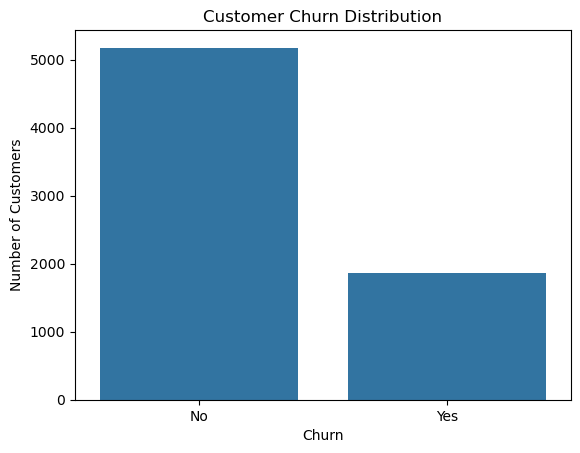

In [252]:
sns.countplot(data=df_clean, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()
#raph for clarity

## Contract Type and Customer Churn

This analysis investigates whether contract type influences customer churn.

In [253]:
pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index") * 100

# % of churn on each contract type

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


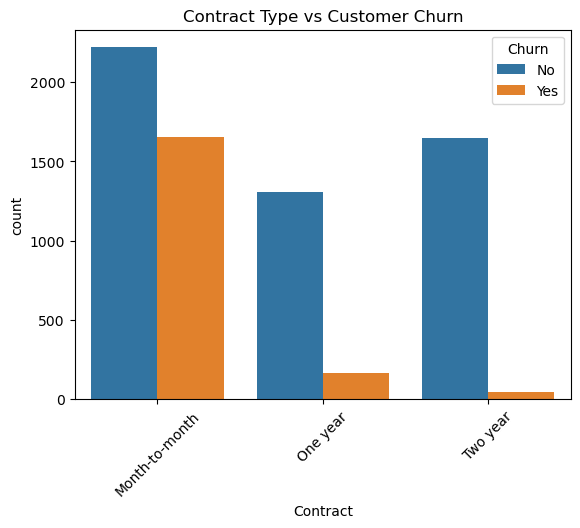

In [254]:
sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn")
plt.title("Contract Type vs Customer Churn")
plt.xticks(rotation=45)
plt.show()

## Customers on a month to month contract show the highest churn rate at 42.71% compared with 11.27% for customers on one year contracts and only 2.83% for customers on 2 year contracts. This shows constract length to be strongly associated with customer retention, with longer term contracts reducing the chances of churn.

## Customer Tenure and Churn

Customer tenure is analysed to understand whether the length of time a customer has stayed with the company affects churn.

In [255]:
df_clean.groupby("Churn")["tenure"].mean()
# shows average time spent for those whoe churned and who didnt

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

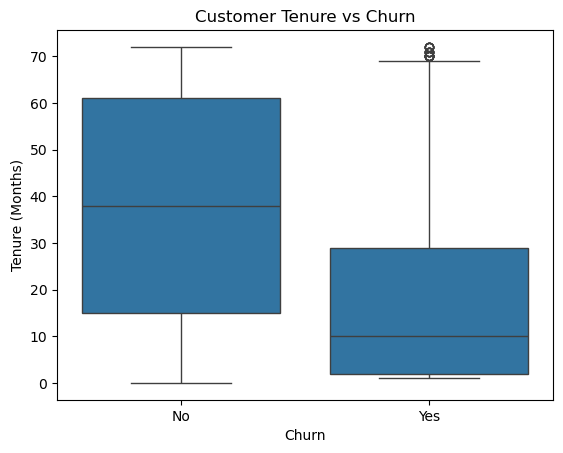

In [256]:
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

## Customers who churn tend to have shorter relationships with the company. This means early customer experience may influence retention.

## Monthly Charges and Churn

This analysis investigates whether the amount customers pay each month is associated with customer churn.

In [257]:
df_clean.groupby("Churn")["MonthlyCharges"].mean()
# average monthly cost for those who churned v who didnt

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

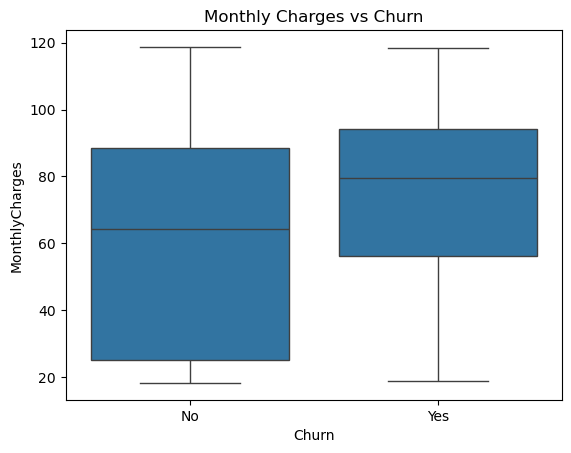

In [258]:
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.show()

## Customers with higher monthly charges appear more likely to churn, showing that pricing may influence retention.

## Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables in the dataset. This shows relationships between numerical features.

In [259]:
correlation_matrix = df_clean.select_dtypes(include="number").corr()
correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


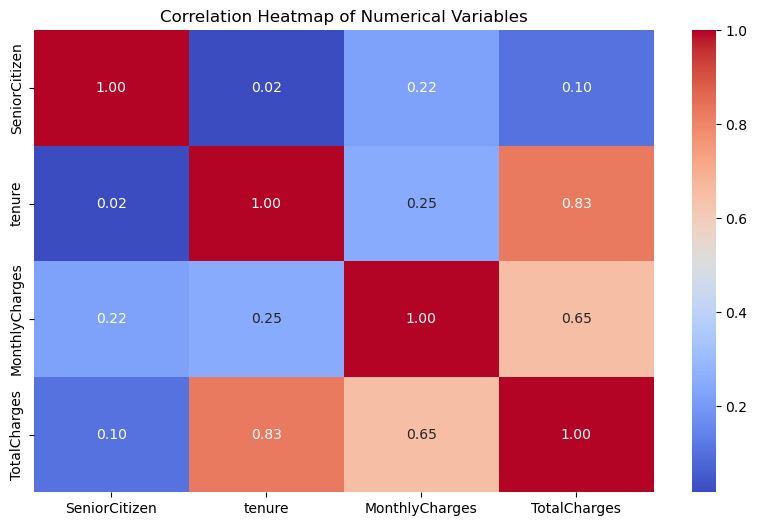

In [260]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [261]:
df_clean.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

## EDA Findings

## EDA Findings

Key observations from the exploratory analysis:

- 26.54% of customers in the dataset have churned, representing 1,869 out of 7,043 customers.
- Customers on monthto mmonth contracts have substantially higher churn rates (42.71%) compared with customers on one year contracts (11.27%) and 2 year contracts (2.83%).
- Customers with shorter tenure appear more likely to churn.
- Monthly charges show differences between customers who churned and those who remained, suggesting a potential relationship between monthly charges and churn.
- The correlation analysis identified relationships between the numerical variables, providing additional insight into the structure of the dataset.

#6. Feature Engineering and Model Preparation

## Define the Target Variable

The target variable for this project is customer churn and this model will use customer characteristics to predict whether a customer is likely to churn.

In [262]:
df_clean["Churn"].value_counts()
# check taget v is corect

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Separate Features and Target

The dataset is separated into input features (X) and the target variable (y). The input features contain have the customer informatio and the target variable represents whether the customer churned.

In [263]:
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

In [264]:
X.shape
# check

(7043, 19)

In [265]:
y.shape

(7043,)

In [266]:
y = y.map({
    "No": 0,
    "Yes": 1})
# binary encoding
#yes = 1 and no = 0

In [267]:
y.head()
# check

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [268]:
X.select_dtypes(include="object").columns
# displays all columns in x with text

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

## Encoding Categorical Variables

The categorical variables are converted into numerical features using one-hot encoding so they can be used by machine learning algorithms.

In [269]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True)
X_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [270]:
X_encoded.shape

(7043, 30)

In [271]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [272]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [273]:
X_encoded.shape

(7043, 30)

## Train-Test Split

The dataset is divided into a training and testing set. The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen customer data.

In [274]:
from sklearn.model_selection import train_test_split

In [275]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    # 20% for testing,
    random_state=42, stratify=y)
#0 = stayed,,1 = churned

In [276]:
X_train.shape

(5634, 30)

In [277]:
X_test.shape

(1409, 30)

In [278]:
y_train.shape

(5634,)

In [279]:
y_test.shape

(1409,)

In [280]:
y_train.value_counts(normalize=True) * 100

Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

In [281]:
y_test.value_counts(normalize=True) * 100

Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64

In [282]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

## Feature Scaling

For logistic regression scaling is useful because it helps prevent variables with larger numerical values from disproportionately affecting the model's optimisation.

In [283]:
from sklearn.preprocessing import StandardScaler

In [284]:
scaler = StandardScaler()

In [285]:
X_train_scaled = scaler.fit_transform(X_train)

In [286]:
X_test_scaled = scaler.transform(X_test)

In [287]:
X_train_scaled.shape

(5634, 30)

In [288]:
X_test_scaled.shape

(1409, 30)

In [289]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64